#  Machine Fault Diagnosis Using Deep Learning Approach 🔩

**Classes:**  Healthy | Misalignment | Bent Shaft | Bearing Fault | Foundation Looseness  
**Approach:** Transfer Learning (EfficientNetB0) + Custom Classification Head  
**Input:** Vibration signal spectrogram-like images (resized to 224×224)

---

## 📦 Install & Import Dependencies

In [1]:
# Install required packages (run once)
#!pip install tensorflow scikit-learn matplotlib seaborn numpy pillow

In [2]:
# Basic system and utility libraries
import os                  # For file and directory handling
import random              # For random operations (reproducibility)
from pathlib import Path   # For structured path handling
from collections import defaultdict

# Numerical and data processing
import numpy as np         # For numerical computations

# Visualization libraries
import matplotlib.pyplot as plt  # For plotting graphs
import seaborn as sns            # For advanced visualization (confusion matrix, etc.)

# Deep Learning Framework (TensorFlow + Keras)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

# Pretrained CNN model (Transfer Learning)
from tensorflow.keras.applications import EfficientNetB0

# Training callbacks (to improve performance)
from tensorflow.keras.callbacks import (
    EarlyStopping,          # Stops training if no improvement
    ReduceLROnPlateau,      # Reduces learning rate when stuck
    ModelCheckpoint         # Saves best model automatically
)

# Optimizer for training
from tensorflow.keras.optimizers import Adam

# Machine Learning utilities
from tensorflow.keras import regularizers
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Image processing
from PIL import Image
# ─────────────────────────────────────────────
# 📊 CHECK ENVIRONMENT
print("🔍 Environment Details:")
print(f"TensorFlow version : {tf.__version__}")
print(f"Keras version      : {keras.__version__}")

🔍 Environment Details:
TensorFlow version : 2.21.0
Keras version      : 3.14.0


In [3]:
# ─────────GPU Configuration───────────────────────
# Purpose:
# - Detect available GPU devices
# - Ensure stable training for CNN models
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ GPU(s) detected and configured: {[g.name for g in gpus]}")
    except RuntimeError as e:
        print(f"⚠️  GPU configuration error: {e}")
else:
    print("ℹ️  No GPU detected — training on CPU (will be slower)")

ℹ️  No GPU detected — training on CPU (will be slower)


## 🗂️ Dataset Loading

In [4]:
def verify_dataset_structure(root_dir):
    """
    Scans your dataset folder and prints a full summary.
    Run this FIRST before any model code.
    """
    print(f"\n{'='*55}")
    print(f"  Dataset Verification: {root_dir}")
    print(f"{'='*55}")

    if not os.path.exists(root_dir):
        print(f"❌ ERROR: Folder not found → {root_dir}")
        return

    class_dirs = sorted([
        d for d in os.listdir(root_dir)
        if os.path.isdir(os.path.join(root_dir, d))
    ])

    if not class_dirs:
        print("❌ ERROR: No class folders found inside root directory.")
        return

    total_images = 0
    class_counts = {}

    for cls in class_dirs:
        cls_path = Path(root_dir) / cls
        subfolders = [
            d for d in os.listdir(cls_path)
            if os.path.isdir(cls_path / d)
        ]

        img_count = len(list(cls_path.rglob("*.png"))) + \
                    len(list(cls_path.rglob("*.jpg")))

        class_counts[cls] = img_count
        total_images += img_count

        print(f"\n  📂 {cls}")
        print(f"     Subfolders : {subfolders}")
        print(f"     Images     : {img_count}")

    print(f"\n{'─'*55}")
    print(f"  Total classes : {len(class_dirs)}")
    print(f"  Total images  : {total_images}")

    # Check for class imbalance
    counts = list(class_counts.values())
    if max(counts) / (min(counts) + 1e-6) > 2.0:
        print("\n  ⚠️  WARNING: Significant class imbalance detected!")
    else:
        print("\n  ✅ Class balance looks good.")
    print(f"{'='*55}\n")

# ── Run verification on all three splits ─────────────────────
verify_dataset_structure("E:\Vedant Giri\Major Project\Dataset\Train")
verify_dataset_structure("E:\Vedant Giri\Major Project\Dataset\Val")
verify_dataset_structure("E:\Vedant Giri\Major Project\Dataset\Test")


  Dataset Verification: E:\Vedant Giri\Major Project\Dataset\Train

  📂 Bearing Fault
     Subfolders : ['CH1', 'CH2', 'CH4']
     Images     : 480

  📂 Bent Shaft
     Subfolders : ['CH1', 'CH2', 'CH4']
     Images     : 480

  📂 Foundation Looseness
     Subfolders : ['CH1', 'CH2', 'CH4']
     Images     : 480

  📂 Healthy
     Subfolders : ['CH1', 'CH2', 'CH4']
     Images     : 480

  📂 Misalignment
     Subfolders : ['CH1', 'CH2', 'CH4']
     Images     : 480

───────────────────────────────────────────────────────
  Total classes : 5
  Total images  : 2400

  ✅ Class balance looks good.


  Dataset Verification: E:\Vedant Giri\Major Project\Dataset\Val

  📂 Bearing Fault
     Subfolders : ['CH1', 'CH2', 'CH4']
     Images     : 60

  📂 Bent Shaft
     Subfolders : ['CH1', 'CH2', 'CH4']
     Images     : 60

  📂 Foundation Looseness
     Subfolders : ['CH1', 'CH2', 'CH4']
     Images     : 60

  📂 Healthy
     Subfolders : ['CH1', 'CH2', 'CH4']
     Images     : 60

  📂 Misalignm

  Loading Dataset
  ✅ Found 2400 images | Classes: ['Bearing Fault', 'Bent Shaft', 'Foundation Looseness', 'Healthy', 'Misalignment']
  ✅ Found 300 images | Classes: ['Bearing Fault', 'Bent Shaft', 'Foundation Looseness', 'Healthy', 'Misalignment']
  ✅ Found 300 images | Classes: ['Bearing Fault', 'Bent Shaft', 'Foundation Looseness', 'Healthy', 'Misalignment']

  Class mapping:
    [0] → Bearing Fault
    [1] → Bent Shaft
    [2] → Foundation Looseness
    [3] → Healthy
    [4] → Misalignment

  Running sanity check...

  ✅ Image shape : (32, 128, 256, 1)
  ✅ Label shape : (32, 5)
  ✅ Pixel range : [0.00, 1.00]
  ✅ Classes     : [0 1 2]


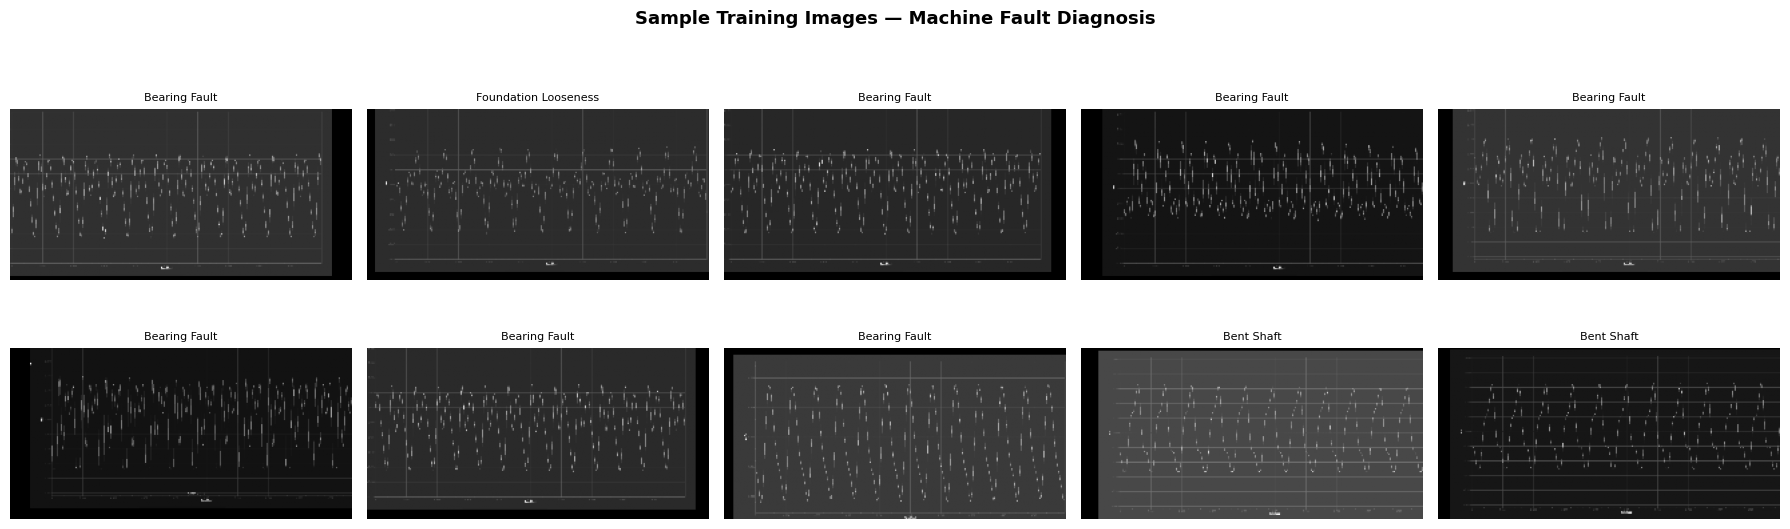


✅ Step 2 Complete — Ready for Step 3!


In [5]:
TRAIN_DIR = ("E:\Vedant Giri\Major Project\Dataset\Train")  
VAL_DIR   = ("E:\Vedant Giri\Major Project\Dataset\Val")  
TEST_DIR  = ("E:\Vedant Giri\Major Project\Dataset\Test") 

IMG_HEIGHT  = 128
IMG_WIDTH   = 256
BATCH_SIZE  = 32
NUM_CLASSES = 5
SEED        = 42

# ── Collect paths & labels ───────────────────────────────────────
def collect_image_paths(root_dir):
    class_names = sorted([
        d for d in os.listdir(root_dir)
        if os.path.isdir(os.path.join(root_dir, d))
        and not d.startswith('.')
    ])
    class_to_idx = {name: idx for idx, name in enumerate(class_names)}

    all_paths, all_labels = [], []
    for class_name in class_names:
        class_dir = Path(root_dir) / class_name
        for img_path in sorted(class_dir.rglob("*.[Pp][Nn][Gg]")):
            all_paths.append(str(img_path))
            all_labels.append(class_to_idx[class_name])
        for img_path in sorted(class_dir.rglob("*.[Jj][Pp][Gg]")):
            all_paths.append(str(img_path))
            all_labels.append(class_to_idx[class_name])

    print(f"  ✅ Found {len(all_paths)} images | Classes: {class_names}")
    return all_paths, all_labels, class_names


# ── Build pipeline using from_generator (avoids dtype bug) ───────
def build_pipeline(root_dir, augment=False, shuffle=False):

    paths, labels, class_names = collect_image_paths(root_dir)

    # ✅ USE from_generator — completely avoids the float32 dtype bug
    def data_generator():
        for path, label in zip(paths, labels):
            yield path, label

    dataset = tf.data.Dataset.from_generator(
        data_generator,
        output_signature=(
            tf.TensorSpec(shape=(), dtype=tf.string),   # path = string
            tf.TensorSpec(shape=(), dtype=tf.int32)     # label = int
        )
    )

    def parse_image(img_path, label):
        img   = tf.io.read_file(img_path)
        img   = tf.image.decode_png(img, channels=1)
        img   = tf.image.resize(img, [IMG_HEIGHT, IMG_WIDTH])
        img   = tf.cast(img, tf.float32) / 255.0
        label = tf.one_hot(label, depth=NUM_CLASSES)
        return img, label

    def augment_image(img, label):
        img = tf.image.random_brightness(img, max_delta=0.1)
        img = tf.image.random_contrast(img, lower=0.9, upper=1.1)
        img = tf.image.resize_with_crop_or_pad(
                  img, IMG_HEIGHT + 16, IMG_WIDTH + 32)
        img = tf.image.random_crop(img, size=[IMG_HEIGHT, IMG_WIDTH, 1])
        img = tf.clip_by_value(img, 0.0, 1.0)
        return img, label

    dataset = dataset.map(parse_image,
                          num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        dataset = dataset.map(augment_image,
                              num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        dataset = dataset.shuffle(buffer_size=1000, seed=SEED)

    dataset = dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return dataset, class_names


# ── Load all splits ──────────────────────────────────────────────
print("=" * 50)
print("  Loading Dataset")
print("=" * 50)

train_ds, class_names = build_pipeline(TRAIN_DIR, augment=True,  shuffle=True)
val_ds,   _           = build_pipeline(VAL_DIR,   augment=False, shuffle=False)
test_ds,  _           = build_pipeline(TEST_DIR,  augment=False, shuffle=False)

print("\n  Class mapping:")
for idx, name in enumerate(class_names):
    print(f"    [{idx}] → {name}")


# ── Sanity check ─────────────────────────────────────────────────
print("\n  Running sanity check...")
for images, labels in train_ds.take(1):
    print(f"\n  ✅ Image shape : {images.shape}")    # (32, 128, 256, 1)
    print(f"  ✅ Label shape : {labels.shape}")     # (32, 5)
    print(f"  ✅ Pixel range : [{images.numpy().min():.2f},"
          f" {images.numpy().max():.2f}]")           # [0.00, 1.00]
    print(f"  ✅ Classes     : "
          f"{np.unique(np.argmax(labels.numpy(), axis=1))}")  # [0 1 2 3 4]

    # Plot sample images
    fig, axes = plt.subplots(2, 5, figsize=(18, 6))
    fig.suptitle("Sample Training Images — Machine Fault Diagnosis",
                 fontsize=13, fontweight='bold')
    for i, ax in enumerate(axes.flat):
        ax.imshow(images[i, :, :, 0].numpy(), cmap='gray')
        ax.set_title(class_names[np.argmax(labels[i].numpy())],
                     fontsize=8)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

print("\n✅ Step 2 Complete — Ready for Step 3!")


── TRAIN batch info ──────────────────
  Image batch shape : (32, 128, 256, 1)
  Label batch shape : (32, 5)
  Pixel range       : [0.00, 1.00]
  Unique labels     : [0 1]


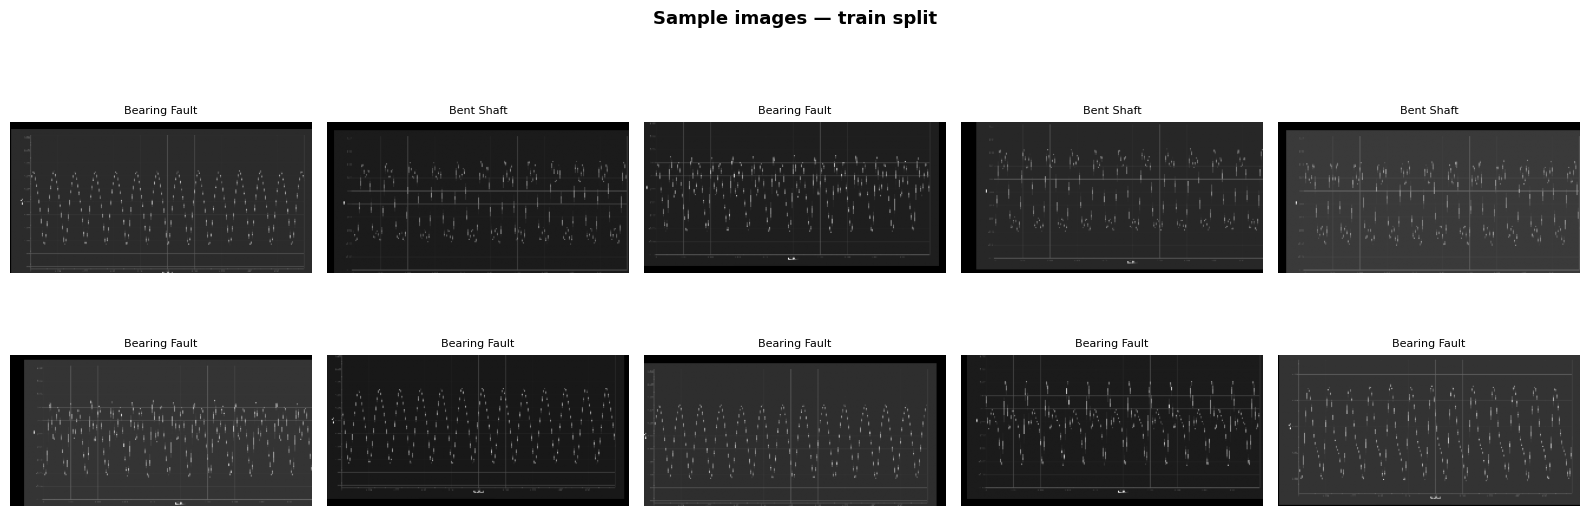


── VAL batch info ──────────────────
  Image batch shape : (32, 128, 256, 1)
  Label batch shape : (32, 5)
  Pixel range       : [0.14, 0.90]
  Unique labels     : [0]


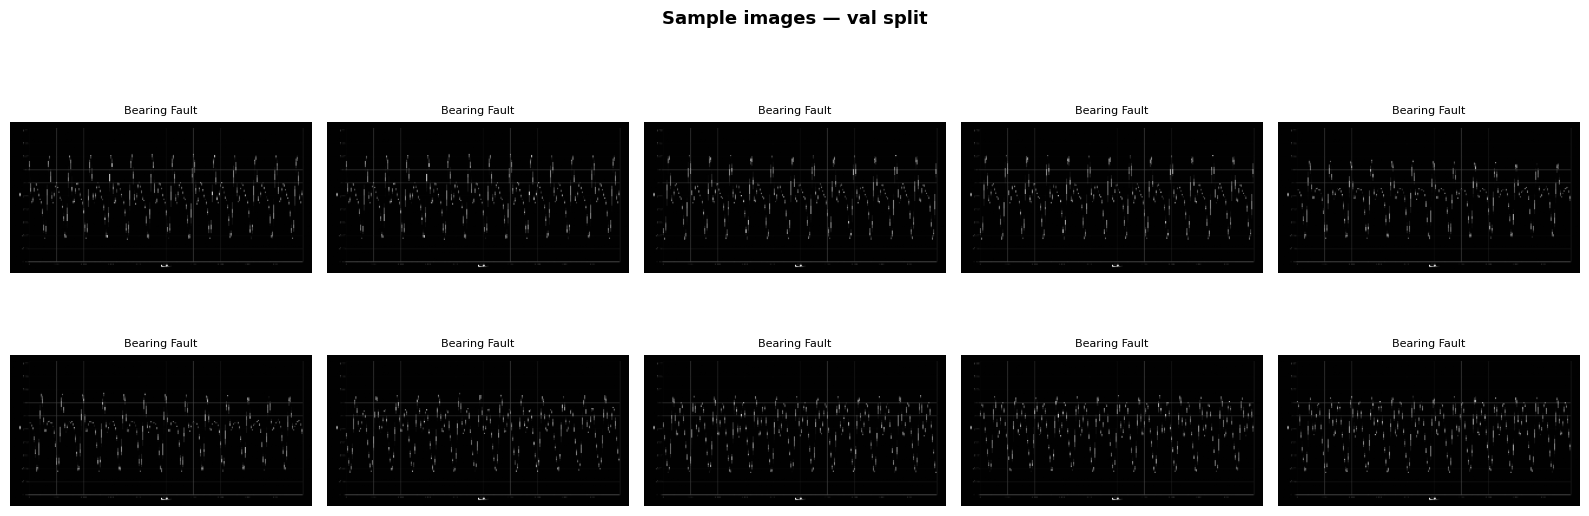

In [6]:
def sanity_check(dataset, class_names, split_name="train"):
    """
    Visualizes one batch — confirm images and labels look correct
    before training.
    """
    for images, labels in dataset.take(1):
        batch_imgs  = images.numpy()
        batch_labels = np.argmax(labels.numpy(), axis=1)

        print(f"\n── {split_name.upper()} batch info ──────────────────")
        print(f"  Image batch shape : {images.shape}")
        # Expected: (32, 128, 256, 1)
        print(f"  Label batch shape : {labels.shape}")
        # Expected: (32, 5)
        print(f"  Pixel range       : "
              f"[{batch_imgs.min():.2f}, {batch_imgs.max():.2f}]")
        # Expected: [0.00, 1.00]
        print(f"  Unique labels     : {np.unique(batch_labels)}")
        # Expected: mix of 0–4

        # Plot 10 sample images
        fig, axes = plt.subplots(2, 5, figsize=(16, 6))
        fig.suptitle(f'Sample images — {split_name} split',
                     fontsize=13, fontweight='bold')
        for idx, ax in enumerate(axes.flat):
            ax.imshow(batch_imgs[idx, :, :, 0], cmap='gray')
            ax.set_title(class_names[batch_labels[idx]],
                         fontsize=8)
            ax.axis('off')
        plt.tight_layout()
        plt.show()

sanity_check(train_ds, class_names, "train")
sanity_check(val_ds,   class_names, "val")

## 💻 Preprocessing & augmentation

In [7]:
# ── Confirm preprocessing is correctly applied ───────────────────
print("=" * 50)
print("  Step 3: Preprocessing Verification")
print("=" * 50)

for images, labels in train_ds.take(1):
    print(f"\n  Image shape  : {images.shape}")
    # ✅ Expected → (32, 128, 256, 1)
    #               batch  H    W   channels(grayscale)

    print(f"  Pixel min    : {images.numpy().min():.4f}")
    # ✅ Expected → 0.0000

    print(f"  Pixel max    : {images.numpy().max():.4f}")
    # ✅ Expected → 1.0000

    print(f"  Pixel mean   : {images.numpy().mean():.4f}")
    # ✅ Expected → somewhere between 0.1 and 0.5

    print(f"  Dtype        : {images.dtype}")
    # ✅ Expected → float32

    print(f"  Channels     : {images.shape[-1]}")
    # ✅ Expected → 1 (grayscale)

print("\n  ✅ Preprocessing confirmed!")

  Step 3: Preprocessing Verification

  Image shape  : (32, 128, 256, 1)
  Pixel min    : 0.0000
  Pixel max    : 0.8779
  Pixel mean   : 0.1470
  Dtype        : <dtype: 'float32'>
  Channels     : 1

  ✅ Preprocessing confirmed!


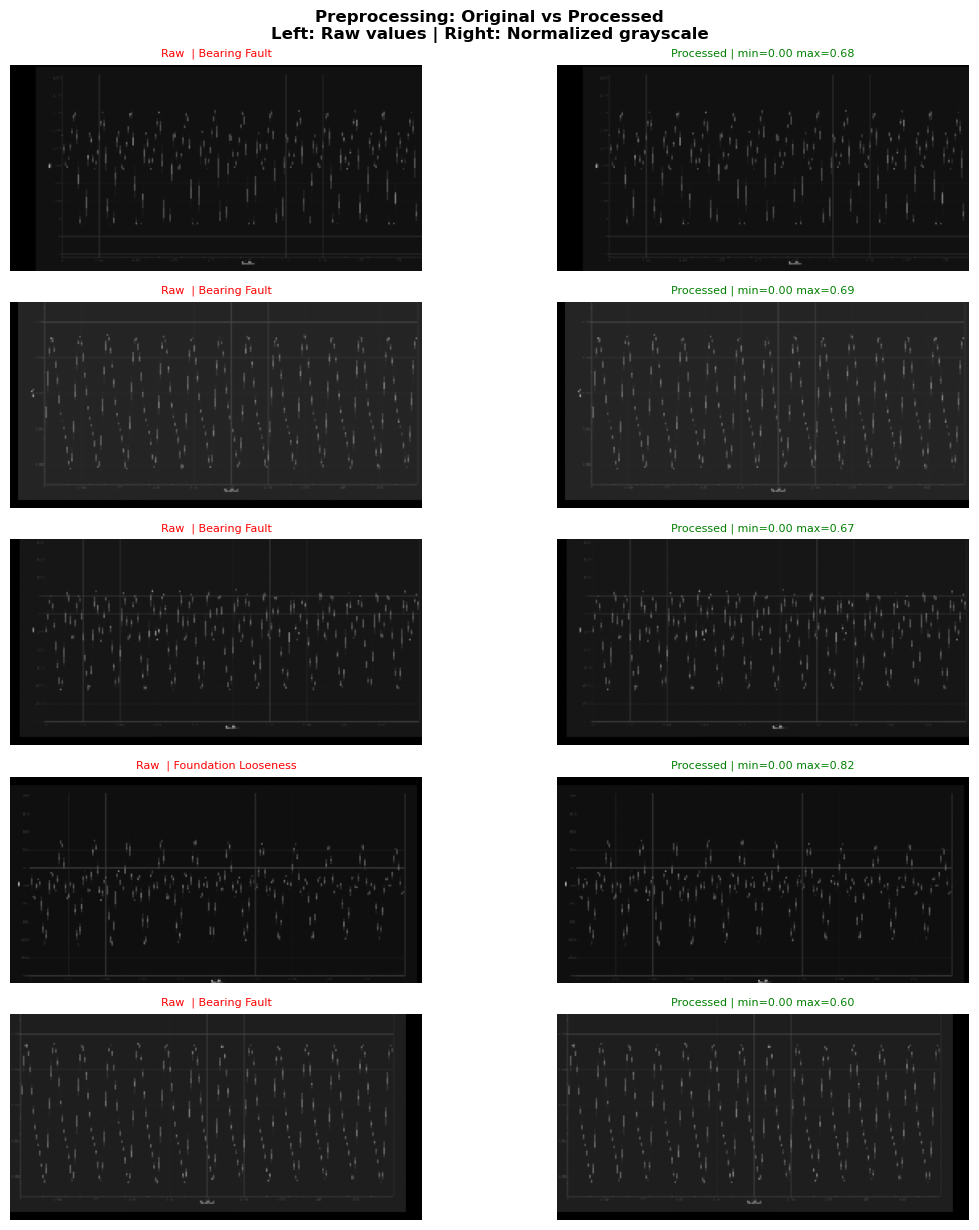

In [8]:
def visualize_preprocessing(dataset, class_names, n=5):
    """
    Shows original (before) vs preprocessed (after) side by side.
    Left  = raw pixel values plotted as-is
    Right = after normalization + grayscale
    """
    for images, labels in dataset.take(1):
        fig, axes = plt.subplots(
            n, 2, figsize=(12, n * 2.5))
        fig.suptitle(
            "Preprocessing: Original vs Processed\n"
            "Left: Raw values | Right: Normalized grayscale",
            fontsize=12, fontweight='bold')

        for i in range(n):
            img        = images[i, :, :, 0].numpy()   # shape (128, 256)
            cls_name   = class_names[np.argmax(labels[i].numpy())]

            # Left: raw (just scale back to 0-255 range for display)
            raw_display = (img * 255).astype(np.uint8)
            axes[i, 0].imshow(raw_display, cmap='gray',
                              vmin=0, vmax=255)
            axes[i, 0].set_title(f"Raw  | {cls_name}",
                                  fontsize=8, color='red')
            axes[i, 0].axis('off')

            # Right: normalized (0.0–1.0)
            axes[i, 1].imshow(img, cmap='gray', vmin=0, vmax=1)
            axes[i, 1].set_title(
                f"Processed | min={img.min():.2f}"
                f" max={img.max():.2f}",
                fontsize=8, color='green')
            axes[i, 1].axis('off')

        plt.tight_layout()
        plt.show()

visualize_preprocessing(train_ds, class_names, n=5)

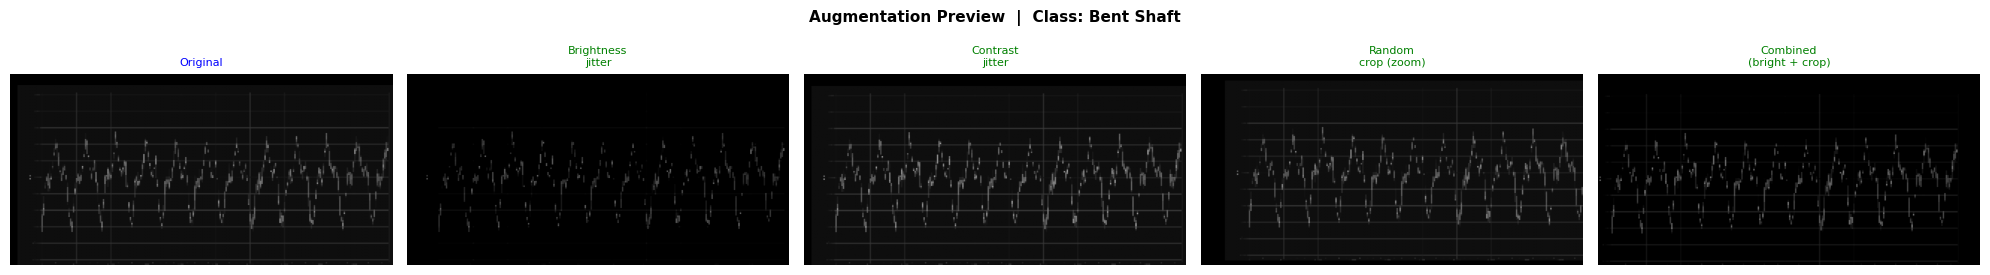

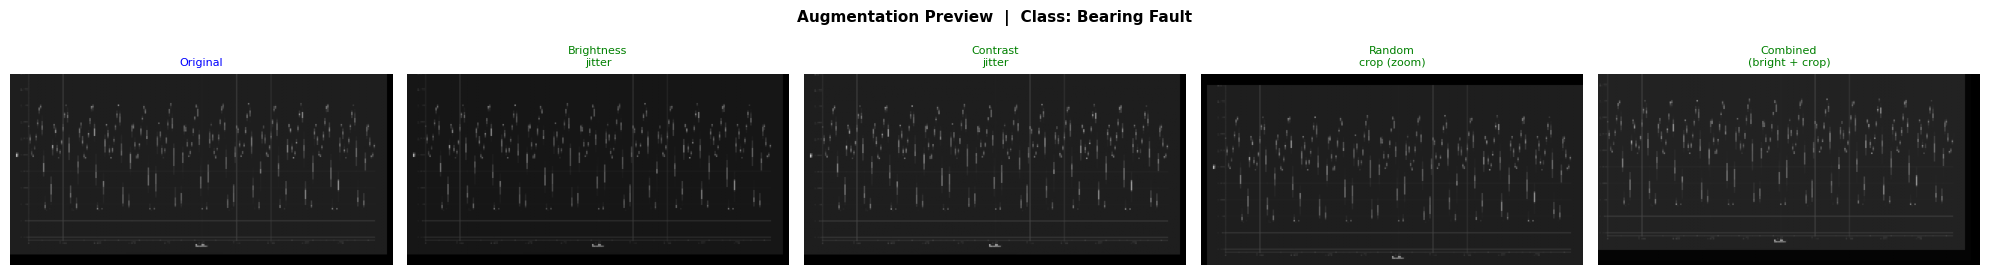

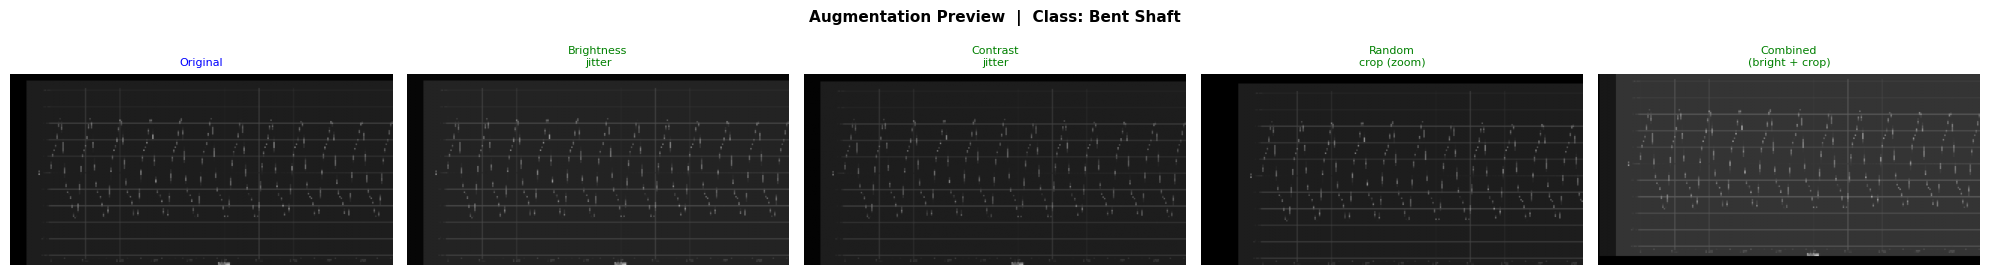

In [9]:
def visualize_augmentation(dataset, class_names, n_images=4):
    """
    Shows 1 original image alongside 4 augmented versions of it.
    Confirms augmentations don't distort waveform meaning.
    """
    import tensorflow as tf

    def augment_single(img):
        """Apply augmentation to a single image for visualization."""

        # Brightness jitter
        aug1 = tf.image.random_brightness(img, max_delta=0.15)
        aug1 = tf.clip_by_value(aug1, 0.0, 1.0)

        # Contrast jitter
        aug2 = tf.image.random_contrast(img, lower=0.85, upper=1.15)
        aug2 = tf.clip_by_value(aug2, 0.0, 1.0)

        # Random crop (zoom simulation)
        padded = tf.image.resize_with_crop_or_pad(
                     img, IMG_HEIGHT + 16, IMG_WIDTH + 32)
        aug3   = tf.image.random_crop(
                     padded, size=[IMG_HEIGHT, IMG_WIDTH, 1])

        # Combined (brightness + crop together)
        aug4 = tf.image.random_brightness(img, max_delta=0.1)
        padded2 = tf.image.resize_with_crop_or_pad(
                      aug4, IMG_HEIGHT + 16, IMG_WIDTH + 32)
        aug4 = tf.image.random_crop(
                   padded2, size=[IMG_HEIGHT, IMG_WIDTH, 1])
        aug4 = tf.clip_by_value(aug4, 0.0, 1.0)

        return [aug1, aug2, aug3, aug4]

    for images, labels in dataset.take(1):
        for sample_idx in range(3):     # show 3 different samples
            original  = images[sample_idx]     # shape (128, 256, 1)
            cls_name  = class_names[
                            np.argmax(labels[sample_idx].numpy())]
            augmented = augment_single(original)

            fig, axes = plt.subplots(1, 5, figsize=(20, 3))
            fig.suptitle(
                f"Augmentation Preview  |  Class: {cls_name}",
                fontsize=11, fontweight='bold')

            titles = [
                "Original",
                "Brightness\njitter",
                "Contrast\njitter",
                "Random\ncrop (zoom)",
                "Combined\n(bright + crop)"
            ]
            imgs_to_show = [original] + augmented

            for j, (ax, aug_img, title) in enumerate(
                    zip(axes, imgs_to_show, titles)):
                ax.imshow(aug_img[:, :, 0].numpy(),
                          cmap='gray', vmin=0, vmax=1)
                ax.set_title(title, fontsize=8,
                             color='blue' if j == 0 else 'green')
                ax.axis('off')

            plt.tight_layout()
            plt.show()

visualize_augmentation(train_ds, class_names)

In [10]:
print("=" * 55)
print("  Augmentation Safety Check for Waveform Images")
print("=" * 55)

augmentations = {
    "Random Brightness (±0.1)"  : "✅ SAFE   — simulates recording condition changes",
    "Random Contrast  (±0.1)"   : "✅ SAFE   — simulates sensor sensitivity variation",
    "Random Crop/Zoom"          : "✅ SAFE   — simulates slight time window shifts",
    "Horizontal Flip"           : "❌ UNSAFE — reverses time axis, changes signal meaning",
    "Vertical Flip"             : "❌ UNSAFE — inverts amplitude, changes fault signature",
    "Rotation"                  : "❌ UNSAFE — waveforms are not rotation invariant",
    "Color Jitter"              : "⚠️  N/A   — already grayscale, no effect",
    "Cutout / Random Erase"     : "⚠️  AVOID — erases waveform peaks = loses key features",
}

for aug, verdict in augmentations.items():
    print(f"  {aug:<35} → {verdict}")

print("=" * 55)

  Augmentation Safety Check for Waveform Images
  Random Brightness (±0.1)            → ✅ SAFE   — simulates recording condition changes
  Random Contrast  (±0.1)             → ✅ SAFE   — simulates sensor sensitivity variation
  Random Crop/Zoom                    → ✅ SAFE   — simulates slight time window shifts
  Horizontal Flip                     → ❌ UNSAFE — reverses time axis, changes signal meaning
  Vertical Flip                       → ❌ UNSAFE — inverts amplitude, changes fault signature
  Rotation                            → ❌ UNSAFE — waveforms are not rotation invariant
  Color Jitter                        → ⚠️  N/A   — already grayscale, no effect
  Cutout / Random Erase               → ⚠️  AVOID — erases waveform peaks = loses key features


In [11]:
def dataset_statistics(dataset, split_name, class_names):
    """
    Computes per-class image count and pixel statistics.
    Run on train, val, and test to confirm everything is healthy.
    """
    class_counts = {name: 0 for name in class_names}
    all_means, all_stds = [], []
    total_images = 0

    for images, labels in dataset:
        batch_labels = np.argmax(labels.numpy(), axis=1)
        for lbl in batch_labels:
            class_counts[class_names[lbl]] += 1
        total_images += images.shape[0]

        # Pixel statistics
        all_means.append(images.numpy().mean())
        all_stds.append(images.numpy().std())

    print(f"\n{'='*50}")
    print(f"  {split_name.upper()} Split Statistics")
    print(f"{'='*50}")
    print(f"  Total images  : {total_images}")
    print(f"  Pixel mean    : {np.mean(all_means):.4f}")
    print(f"  Pixel std     : {np.mean(all_stds):.4f}")
    print(f"\n  Per-class counts:")
    for cls, count in class_counts.items():
        bar = "█" * (count // 50)
        print(f"    {cls:<35} : {count:>5}  {bar}")
    print(f"{'='*50}")

dataset_statistics(train_ds, "train", class_names)
dataset_statistics(val_ds,   "val",   class_names)
dataset_statistics(test_ds,  "test",  class_names)


  TRAIN Split Statistics
  Total images  : 2400
  Pixel mean    : 0.1471
  Pixel std     : 0.0786

  Per-class counts:
    Bearing Fault                       :   480  █████████
    Bent Shaft                          :   480  █████████
    Foundation Looseness                :   480  █████████
    Healthy                             :   480  █████████
    Misalignment                        :   480  █████████

  VAL Split Statistics
  Total images  : 300
  Pixel mean    : 0.1554
  Pixel std     : 0.0418

  Per-class counts:
    Bearing Fault                       :    60  █
    Bent Shaft                          :    60  █
    Foundation Looseness                :    60  █
    Healthy                             :    60  █
    Misalignment                        :    60  █

  TEST Split Statistics
  Total images  : 300
  Pixel mean    : 0.1554
  Pixel std     : 0.0418

  Per-class counts:
    Bearing Fault                       :    60  █
    Bent Shaft                          :   

In [12]:
"""
╔══════════════════════════════════════════════════════╗
║         Step 3 Complete — Preprocessing Summary      ║
╠══════════════════════════════════════════════════════╣
║  Input size      : 1900 × 900 px (original)          ║
║  Resized to      : 256  × 128 px                     ║
║  Color mode      : Grayscale (1 channel)             ║
║  Normalization   : [0, 1]  (÷ 255)                   ║
║  Dtype           : float32                           ║
╠══════════════════════════════════════════════════════╣
║  Augmentations (train only):                         ║
║    • Random brightness  ±0.1                         ║
║    • Random contrast    ±0.1                         ║
║    • Random crop/zoom   +16px H / +32px W pad        ║
║  No augmentation on val / test                       ║
╠══════════════════════════════════════════════════════╣
║  Pipeline speed  : AUTOTUNE + prefetch               ║
║  Batch size      : 32                                ║
╚══════════════════════════════════════════════════════╝
"""

'\n╔══════════════════════════════════════════════════════╗\n║         Step 3 Complete — Preprocessing Summary      ║\n╠══════════════════════════════════════════════════════╣\n║  Input size      : 1900 × 900 px (original)          ║\n║  Resized to      : 256  × 128 px                     ║\n║  Color mode      : Grayscale (1 channel)             ║\n║  Normalization   : [0, 1]  (÷ 255)                   ║\n║  Dtype           : float32                           ║\n╠══════════════════════════════════════════════════════╣\n║  Augmentations (train only):                         ║\n║    • Random brightness  ±0.1                         ║\n║    • Random contrast    ±0.1                         ║\n║    • Random crop/zoom   +16px H / +32px W pad        ║\n║  No augmentation on val / test                       ║\n╠══════════════════════════════════════════════════════╣\n║  Pipeline speed  : AUTOTUNE + prefetch               ║\n║  Batch size      : 32                                ║\n╚══════════

In [13]:
#checking
print("Classes found:", class_names)
print("Total classes:", len(class_names))
# Must print exactly 5 class names

Classes found: ['Bearing Fault', 'Bent Shaft', 'Foundation Looseness', 'Healthy', 'Misalignment']
Total classes: 5


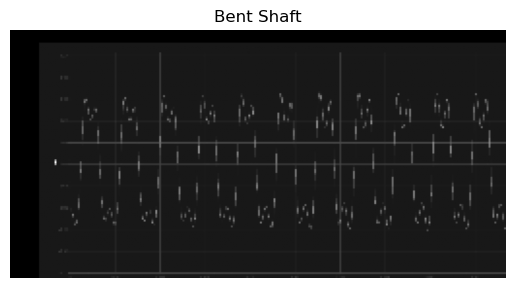

In [14]:
#checking
# Pull one image and display it
for images, labels in train_ds.take(1):
    plt.imshow(images[0, :, :, 0].numpy(), cmap='gray')
    plt.title(class_names[np.argmax(labels[0].numpy())])
    plt.axis('off')
    plt.show()
    # You should see a clear waveform graph

In [15]:
#checking 
train_count = sum(1 for _ in train_ds) * BATCH_SIZE
val_count   = sum(1 for _ in val_ds)   * BATCH_SIZE
test_count  = sum(1 for _ in test_ds)  * BATCH_SIZE

print(f"Train : {train_count}")
print(f"Val   : {val_count}")
print(f"Test  : {test_count}")

val_ratio  = val_count  / train_count * 100
test_ratio = test_count / train_count * 100
print(f"\nVal  is {val_ratio:.1f}% of train  → ideal: 15–25%")
print(f"Test is {test_ratio:.1f}% of train → ideal: 10–20%")

Train : 2400
Val   : 320
Test  : 320

Val  is 13.3% of train  → ideal: 15–25%
Test is 13.3% of train → ideal: 10–20%


## 🏗️ CNN Model Architecture

In [16]:
def build_cnn_model(input_shape=(128, 256, 1), num_classes=5):
    """
    Custom CNN for Machine Fault Diagnosis
    Architecture: 4 Conv Blocks → GlobalAvgPool → Dense → Softmax
    
    Block structure:
        Conv2D → BatchNorm → ReLU → Conv2D → BatchNorm → ReLU
        → MaxPool → Dropout
    """

    inputs = tf.keras.Input(shape=input_shape, name="input_waveform")

    # ════════════════════════════════════════════════════
    # BLOCK 1 — Low-level feature detection
    # Learns: edges, basic waveform curves
    # Filters: 32  |  Dropout: 0.1 (light)
    # ════════════════════════════════════════════════════
    x = layers.Conv2D(32, (3, 3), padding='same',
                      kernel_regularizer=regularizers.l2(1e-4),
                      name='block1_conv1')(inputs)
    x = layers.BatchNormalization(name='block1_bn1')(x)
    x = layers.Activation('relu', name='block1_relu1')(x)

    x = layers.Conv2D(32, (3, 3), padding='same',
                      kernel_regularizer=regularizers.l2(1e-4),
                      name='block1_conv2')(x)
    x = layers.BatchNormalization(name='block1_bn2')(x)
    x = layers.Activation('relu', name='block1_relu2')(x)

    x = layers.MaxPooling2D((2, 2), name='block1_pool')(x)
    x = layers.Dropout(0.1, name='block1_drop')(x)
    # Output: 64 × 128 × 32

    # ════════════════════════════════════════════════════
    # BLOCK 2 — Mid-level feature detection
    # Learns: waveform amplitude patterns, peak shapes
    # Filters: 64  |  Dropout: 0.2
    # ════════════════════════════════════════════════════
    x = layers.Conv2D(64, (3, 3), padding='same',
                      kernel_regularizer=regularizers.l2(1e-4),
                      name='block2_conv1')(x)
    x = layers.BatchNormalization(name='block2_bn1')(x)
    x = layers.Activation('relu', name='block2_relu1')(x)

    x = layers.Conv2D(64, (3, 3), padding='same',
                      kernel_regularizer=regularizers.l2(1e-4),
                      name='block2_conv2')(x)
    x = layers.BatchNormalization(name='block2_bn2')(x)
    x = layers.Activation('relu', name='block2_relu2')(x)

    x = layers.MaxPooling2D((2, 2), name='block2_pool')(x)
    x = layers.Dropout(0.2, name='block2_drop')(x)
    # Output: 32 × 64 × 64

    # ════════════════════════════════════════════════════
    # BLOCK 3 — High-level feature detection
    # Learns: fault-specific frequency patterns
    # Filters: 128  |  Dropout: 0.3
    # ════════════════════════════════════════════════════
    x = layers.Conv2D(128, (3, 3), padding='same',
                      kernel_regularizer=regularizers.l2(1e-4),
                      name='block3_conv1')(x)
    x = layers.BatchNormalization(name='block3_bn1')(x)
    x = layers.Activation('relu', name='block3_relu1')(x)

    x = layers.Conv2D(128, (3, 3), padding='same',
                      kernel_regularizer=regularizers.l2(1e-4),
                      name='block3_conv2')(x)
    x = layers.BatchNormalization(name='block3_bn2')(x)
    x = layers.Activation('relu', name='block3_relu2')(x)

    x = layers.MaxPooling2D((2, 2), name='block3_pool')(x)
    x = layers.Dropout(0.3, name='block3_drop')(x)
    # Output: 16 × 32 × 128

    # ════════════════════════════════════════════════════
    # BLOCK 4 — Abstract feature detection
    # Learns: complex fault signatures across full waveform
    # Filters: 256  |  Dropout: 0.3
    # ════════════════════════════════════════════════════
    x = layers.Conv2D(256, (3, 3), padding='same',
                      kernel_regularizer=regularizers.l2(1e-4),
                      name='block4_conv1')(x)
    x = layers.BatchNormalization(name='block4_bn1')(x)
    x = layers.Activation('relu', name='block4_relu1')(x)

    x = layers.Conv2D(256, (3, 3), padding='same',
                      kernel_regularizer=regularizers.l2(1e-4),
                      name='block4_conv2')(x)
    x = layers.BatchNormalization(name='block4_bn2')(x)
    x = layers.Activation('relu', name='block4_relu2')(x)

    x = layers.MaxPooling2D((2, 2), name='block4_pool')(x)
    x = layers.Dropout(0.3, name='block4_drop')(x)
    # Output: 8 × 16 × 256

    # ════════════════════════════════════════════════════
    # CLASSIFIER HEAD
    # GlobalAvgPool → Dense → Dropout → Softmax
    # ════════════════════════════════════════════════════

    # GlobalAveragePooling — better than Flatten for generalization
    # Takes mean of each feature map → less overfitting
    x = layers.GlobalAveragePooling2D(name='global_avg_pool')(x)
    # Output: 256

    x = layers.Dense(256, name='dense_1')(x)
    x = layers.BatchNormalization(name='dense_bn')(x)
    x = layers.Activation('relu', name='dense_relu')(x)
    x = layers.Dropout(0.5, name='dense_drop')(x)
    # Output: 256

    # Final classification layer
    outputs = layers.Dense(num_classes,
                           activation='softmax',
                           name='output')(x)
    # Output: 5 (one probability per fault class)

    model = models.Model(inputs=inputs,
                         outputs=outputs,
                         name='MachineFaultCNN')
    return model


# ── Build the model ───────────────────────────────────────────────
model = build_cnn_model(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 1),
    num_classes=NUM_CLASSES
)

print("✅ Model built successfully!")

✅ Model built successfully!


In [17]:
# ── Compile ───────────────────────────────────────────────────────
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',   # multi-class classification
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

print("✅ Model compiled!")
print(f"   Optimizer : Adam  (lr=0.001)")
print(f"   Loss      : categorical_crossentropy")
print(f"   Metrics   : accuracy, precision, recall")

✅ Model compiled!
   Optimizer : Adam  (lr=0.001)
   Loss      : categorical_crossentropy
   Metrics   : accuracy, precision, recall


In [18]:
# ── Full architecture summary ────────────────────────────────────
model.summary()

Model: "MachineFaultCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_waveform (InputLayer)     │ (None, 128, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 256, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_bn1 (BatchNormalization) │ (None, 128, 256, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_relu1 (Activation)       │ (None, 128, 256, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 256, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_bn2 (BatchNormalization) │ (None, 128, 256, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_relu2 (Activation)       │ (None, 128, 256, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 128, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_drop (Dropout)           │ (None, 64, 128, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 128, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_bn1 (BatchNormalization) │ (None, 64, 128, 64)    │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_relu1 (Activation)       │ (None, 64, 128, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 128, 64)    │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_bn2 (BatchNormalization) │ (None, 64, 128, 64)    │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_relu2 (Activation)       │ (None, 64, 128, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_drop (Dropout)           │ (None, 32, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_bn1 (BatchNormalization) │ (None, 32, 64, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_relu1 (Activation)       │ (None, 32, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 32, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_bn2 (BatchNormalization) │ (None, 32, 64, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_relu2 (Activation)       │ (None, 32, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_drop (Dropout)           │ (None, 16, 32, 128)    │             

 Total params: 1,243,621 (4.74 MB)

 Trainable params: 1,241,189 (4.73 MB)

 Non-trainable params: 2,432 (9.50 KB)

In [19]:
# ── Test the model with one real batch ───────────────────────────
print("Running test forward pass...\n")

for images, labels in train_ds.take(1):
    predictions = model(images, training=False)

    print(f"  Input shape       : {images.shape}")
    # Expected → (32, 128, 256, 1)

    print(f"  Output shape      : {predictions.shape}")
    # Expected → (32, 5)

    print(f"  Output sum check  : {predictions[0].numpy().sum():.4f}")
    # Expected → 1.0000 (softmax probabilities sum to 1)

    print(f"\n  Sample prediction probabilities (untrained):")
    for i in range(3):
        probs     = predictions[i].numpy()
        predicted = class_names[probs.argmax()]
        true_lbl  = class_names[labels[i].numpy().argmax()]
        print(f"    Sample {i+1}: "
              f"True={true_lbl:<30} "
              f"Pred={predicted:<30} "
              f"Confidence={probs.max():.2%}")

print("\n✅ Forward pass successful — model is ready to train!")

Running test forward pass...

  Input shape       : (32, 128, 256, 1)
  Output shape      : (32, 5)
  Output sum check  : 1.0000

  Sample prediction probabilities (untrained):
    Sample 1: True=Bent Shaft                     Pred=Bearing Fault                  Confidence=20.08%
    Sample 2: True=Bent Shaft                     Pred=Bearing Fault                  Confidence=20.08%
    Sample 3: True=Bearing Fault                  Pred=Bearing Fault                  Confidence=20.05%

✅ Forward pass successful — model is ready to train!


In [20]:
# ── Parameter breakdown ───────────────────────────────────────────
total_params     = model.count_params()
trainable_params = sum([
    tf.size(w).numpy() for w in model.trainable_weights
])

print("=" * 50)
print("  Model Parameter Summary")
print("=" * 50)
print(f"  Total parameters     : {total_params:,}")
print(f"  Trainable parameters : {trainable_params:,}")
print(f"  Non-trainable        : {total_params - trainable_params:,}")
print(f"\n  Model size estimate  : "
      f"~{total_params * 4 / 1024 / 1024:.1f} MB")
print("=" * 50)

# Guidance
if total_params < 500_000:
    print("  ⚠️  Model may be too small — consider adding a block")
elif total_params < 5_000_000:
    print("  ✅ Good size — well matched to your dataset")
else:
    print("  ⚠️  Model is large — monitor for overfitting")

  Model Parameter Summary
  Total parameters     : 1,243,621
  Trainable parameters : 1,241,189
  Non-trainable        : 2,432

  Model size estimate  : ~4.7 MB
  ✅ Good size — well matched to your dataset


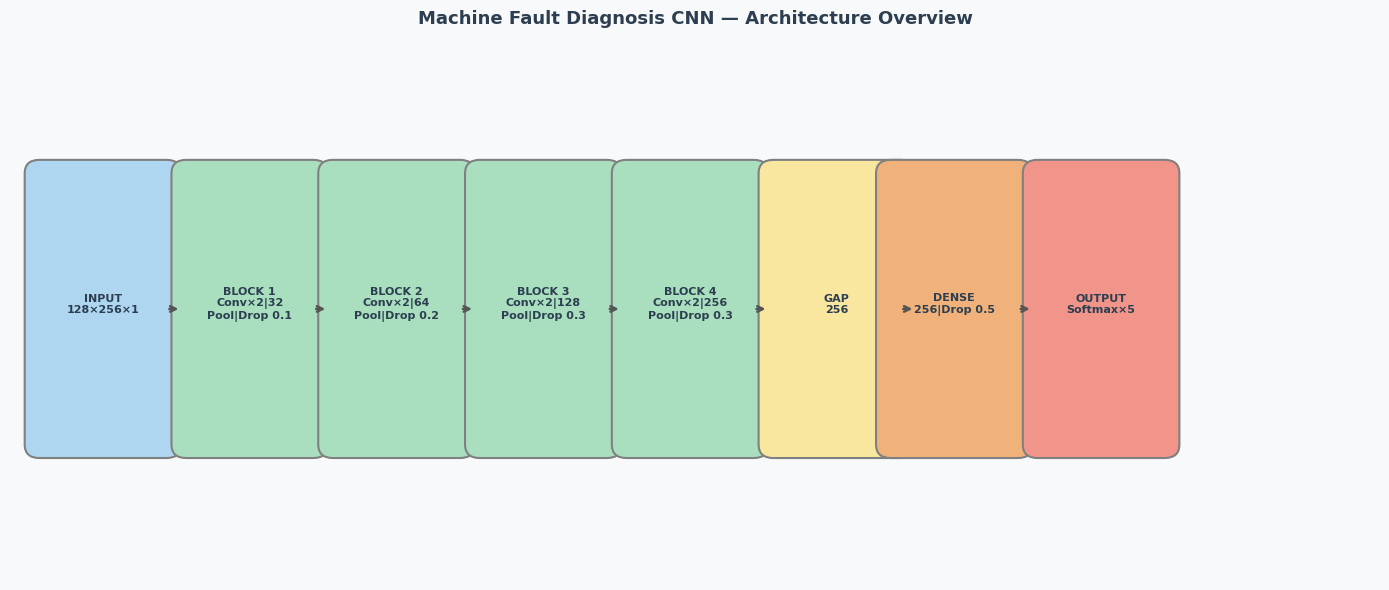

In [21]:
# ── Visual block diagram ──────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(14, 6))
ax.set_xlim(0, 14)
ax.set_ylim(0, 6)
ax.axis('off')
fig.patch.set_facecolor('#f8f9fa')

blocks = [
    ("INPUT\n128×256×1",        "#AED6F1", 0.3),
    ("BLOCK 1\nConv×2|32\nPool|Drop 0.1",  "#A9DFBF", 1.8),
    ("BLOCK 2\nConv×2|64\nPool|Drop 0.2",  "#A9DFBF", 3.3),
    ("BLOCK 3\nConv×2|128\nPool|Drop 0.3", "#A9DFBF", 4.8),
    ("BLOCK 4\nConv×2|256\nPool|Drop 0.3", "#A9DFBF", 6.3),
    ("GAP\n256",                "#F9E79F", 7.8),
    ("DENSE\n256|Drop 0.5",     "#F0B27A", 9.0),
    ("OUTPUT\nSoftmax×5",       "#F1948A", 10.5),
]

for label, color, x in blocks:
    rect = mpatches.FancyBboxPatch(
        (x, 1.5), 1.3, 3.0,
        boxstyle="round,pad=0.15",
        facecolor=color, edgecolor='gray',
        linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x + 0.65, 3.05, label,
            ha='center', va='center',
            fontsize=8, fontweight='bold',
            color='#2C3E50')

    # Arrow
    if x < 10.5:
        ax.annotate('', xy=(x + 1.45, 3.0),
                    xytext=(x + 1.3, 3.0),
                    arrowprops=dict(
                        arrowstyle='->', color='#555',
                        lw=1.8))

ax.set_title(
    "Machine Fault Diagnosis CNN — Architecture Overview",
    fontsize=13, fontweight='bold',
    color='#2C3E50', pad=10)

plt.tight_layout()
plt.show()

## ⚙️ Training Strategy

In [22]:
import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import callbacks

# ── Directory to save best model ──────────────────────────────
os.makedirs("saved_models", exist_ok=True)
os.makedirs("logs",         exist_ok=True)

# ════════════════════════════════════════════════════════════════
# CALLBACK 1 — ModelCheckpoint
# Saves the best model weights automatically during training.
# Only saves when val_accuracy improves — no manual saving needed.
# ════════════════════════════════════════════════════════════════
checkpoint_cb = callbacks.ModelCheckpoint(
    filepath        = "saved_models/best_model.keras",
    monitor         = 'val_accuracy',   # watch validation accuracy
    save_best_only  = True,             # only save when it improves
    save_weights_only = False,          # save full model, not just weights
    mode            = 'max',            # higher accuracy = better
    verbose         = 1                 # print when saved
)

# ════════════════════════════════════════════════════════════════
# CALLBACK 2 — EarlyStopping
# Stops training automatically when model stops improving.
# Prevents wasted time and overfitting.
# patience=12 means: stop if no improvement for 12 epochs.
# restore_best_weights: rolls back to the best epoch on stop.
# ════════════════════════════════════════════════════════════════
early_stop_cb = callbacks.EarlyStopping(
    monitor              = 'val_accuracy',
    patience             = 5,          # wait 5 epochs before stopping
    restore_best_weights = True,        # go back to best epoch weights
    mode                 = 'max',
    verbose              = 1
)

# ════════════════════════════════════════════════════════════════
# CALLBACK 3 — ReduceLROnPlateau
# Automatically reduces learning rate when training gets stuck.
# factor=0.5 → halves the LR each time it triggers.
# patience=5  → waits 5 epochs before reducing.
# min_lr      → never goes below this value.
# ════════════════════════════════════════════════════════════════
reduce_lr_cb = callbacks.ReduceLROnPlateau(
    monitor   = 'val_loss',
    factor    = 0.5,            # new_lr = old_lr * 0.5
    patience  = 5,              # wait 5 epochs before reducing
    min_lr    = 1e-7,           # absolute minimum LR
    mode      = 'min',
    verbose   = 1
)

# ════════════════════════════════════════════════════════════════
# CALLBACK 4 — CSVLogger
# Saves training history to a CSV file.
# Useful for plotting later even after kernel restarts.
# ════════════════════════════════════════════════════════════════
csv_logger_cb = callbacks.CSVLogger(
    "logs/training_log.csv",
    separator = ',',
    append    = False           # overwrite each time
)

# ── Combine all callbacks into one list ───────────────────────
all_callbacks = [
    checkpoint_cb,
    early_stop_cb,
    reduce_lr_cb,
    csv_logger_cb
]

print("=" * 50)
print("  Callbacks Ready")
print("=" * 50)
print("  ✅ ModelCheckpoint  → saved_models/best_model.keras")
print("  ✅ EarlyStopping    → patience = 12 epochs")
print("  ✅ ReduceLROnPlateau→ patience = 5  epochs")
print("  ✅ CSVLogger        → logs/training_log.csv")
print("=" * 50)

  Callbacks Ready
  ✅ ModelCheckpoint  → saved_models/best_model.keras
  ✅ EarlyStopping    → patience = 12 epochs
  ✅ ReduceLROnPlateau→ patience = 5  epochs
  ✅ CSVLogger        → logs/training_log.csv


In [23]:
# ════════════════════════════════════════════════════════════════
# TRAINING
# EPOCHS = 100  → but EarlyStopping will likely stop it earlier
# The model will automatically:
#   - Save best weights   (ModelCheckpoint)
#   - Reduce LR if stuck  (ReduceLROnPlateau)
#   - Stop when plateau   (EarlyStopping)
# ════════════════════════════════════════════════════════════════

EPOCHS = 30   # upper limit — early stopping handles the rest

print("=" * 55)
print("  Starting Training — Machine Fault Diagnosis CNN")
print("=" * 55)
print(f"  Max epochs     : {EPOCHS}")
print(f"  Batch size     : {BATCH_SIZE}")
print(f"  Input shape    : ({IMG_HEIGHT}, {IMG_WIDTH}, 1)")
print(f"  Classes        : {NUM_CLASSES}")
print(f"  Initial LR     : 0.001")
print("=" * 55)
print()

# ── FIX: Repeat dataset so it doesn't run out ──
train_ds = train_ds.repeat()
val_ds   = val_ds.repeat()

# ── FIX: Define steps per epoch (adjust if needed) ──
steps_per_epoch = 100
validation_steps = 20

history = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs          = EPOCHS,
    steps_per_epoch = steps_per_epoch,
    validation_steps= validation_steps,
    callbacks       = all_callbacks,
    verbose         = 1
)

print()
print("=" * 55)
print("  Training Complete!")
print(f"  Epochs run       : {len(history.history['accuracy'])}")
print(f"  Best val accuracy: {max(history.history['val_accuracy']):.4f}")
print(f"  Best val loss    : {min(history.history['val_loss']):.4f}")
print("=" * 55)

  Starting Training — Machine Fault Diagnosis CNN
  Max epochs     : 30
  Batch size     : 32
  Input shape    : (128, 256, 1)
  Classes        : 5
  Initial LR     : 0.001

Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5914 - loss: 1.2932 - precision: 0.6496 - recall: 0.4986
Epoch 1: val_accuracy improved from None to 0.20000, saving model to saved_models/best_model.keras

Epoch 1: finished saving model to saved_models/best_model.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 437s 4s/step - accuracy: 0.7000 - loss: 1.0197 - precision: 0.7567 - recall: 0.6366 - val_accuracy: 0.2000 - val_loss: 20.7340 - val_precision: 0.2000 - val_recall: 0.2000 - learning_rate: 0.0010
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 19s/step - accuracy: 0.8534 - loss: 0.5190 - precision: 0.8678 - recall: 0.8326 
Epoch 2: val_accuracy did not improve from 0.20000
100/100 ━━━━━━━━━━━━━━━━━━━━ 1908s 19s/step - accuracy: 0.8863 - loss: 0.4352 - precision: 0.8981 - recall: 0.8706 - val_accuracy: 0.2000 - 

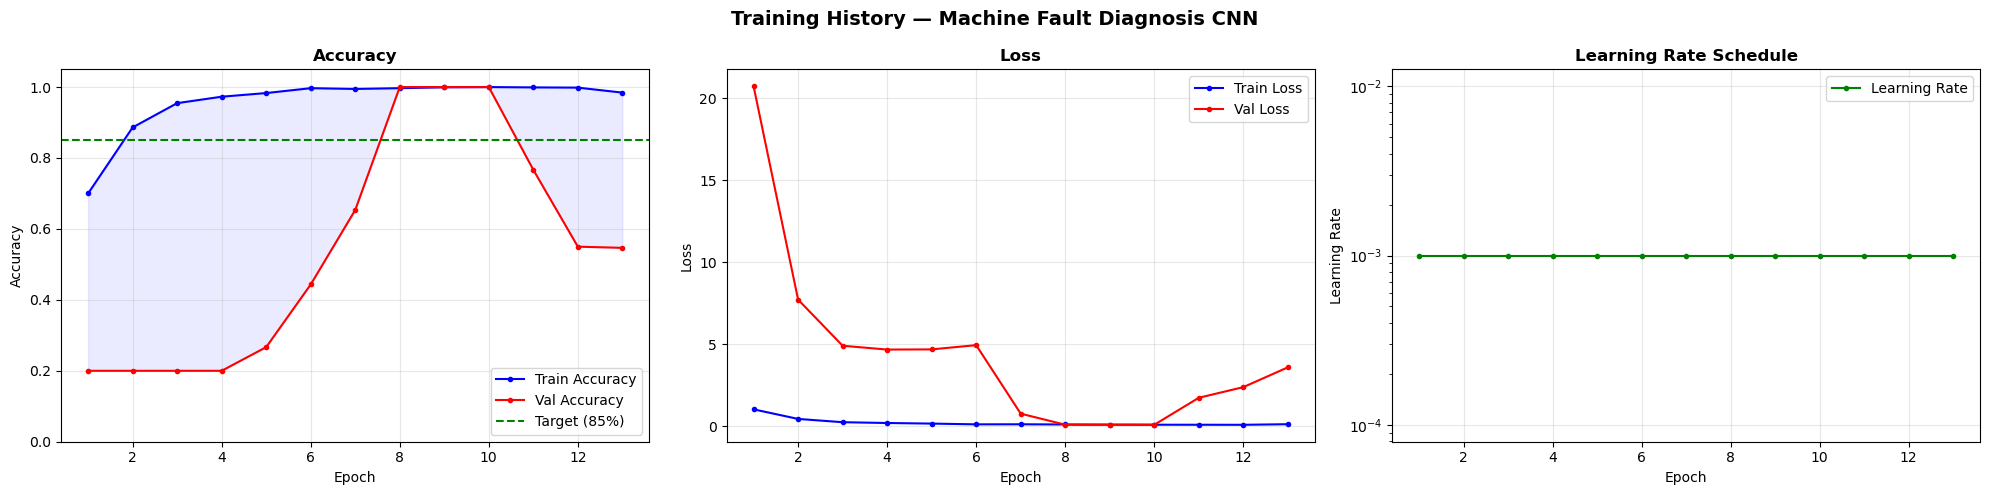

✅ Training curves saved → logs/training_curves.png


In [24]:
def plot_training_history(history):
    """
    Plots 4 graphs:
      - Training vs Validation Accuracy
      - Training vs Validation Loss
      - Learning Rate over epochs
      - Precision & Recall over epochs
    """
    acc      = history.history['accuracy']
    val_acc  = history.history['val_accuracy']
    loss     = history.history['loss']
    val_loss = history.history['val_loss']
    lr       = history.history.get('lr', [0.001] * len(acc))
    epochs   = range(1, len(acc) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    fig.suptitle(
        'Training History — Machine Fault Diagnosis CNN',
        fontsize=14, fontweight='bold')

    # ── Plot 1: Accuracy ────────────────────────────────────
    axes[0].plot(epochs, acc,     'b-o', markersize=3,
                 label='Train Accuracy')
    axes[0].plot(epochs, val_acc, 'r-o', markersize=3,
                 label='Val Accuracy')
    axes[0].axhline(y=0.85, color='green', linestyle='--',
                    linewidth=1.5, label='Target (85%)')
    axes[0].fill_between(epochs, acc, val_acc,
                          alpha=0.08, color='blue')
    axes[0].set_title('Accuracy', fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].set_ylim(0, 1.05)

    # ── Plot 2: Loss ─────────────────────────────────────────
    axes[1].plot(epochs, loss,     'b-o', markersize=3,
                 label='Train Loss')
    axes[1].plot(epochs, val_loss, 'r-o', markersize=3,
                 label='Val Loss')
    axes[1].set_title('Loss', fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # ── Plot 3: Learning Rate ─────────────────────────────────
    axes[2].plot(epochs, lr, 'g-o', markersize=3,
                 label='Learning Rate')
    axes[2].set_title('Learning Rate Schedule', fontweight='bold')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Learning Rate')
    axes[2].set_yscale('log')           # log scale for LR
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('logs/training_curves.png', dpi=150,
                bbox_inches='tight')
    plt.show()
    print("✅ Training curves saved → logs/training_curves.png")

plot_training_history(history)

## 📈 Evaluation Metrics & Model Performance

In [25]:
# ════════════════════════════════════════════════════════════════
# Always evaluate using the BEST saved model (not last epoch)
# The last epoch may be slightly overfit —
# the saved checkpoint is the peak validation accuracy epoch.
# ════════════════════════════════════════════════════════════════

print("Loading best saved model...")
best_model = tf.keras.models.load_model("saved_models/best_model.keras")
print("✅ Best model loaded successfully!\n")

# ── Evaluate on test set ──────────────────────────────────────
print("=" * 50)
print("  Evaluating on TEST set...")
print("=" * 50)

test_results = best_model.evaluate(test_ds, verbose=1)

print()
print("=" * 50)
print("  TEST SET RESULTS")
print("=" * 50)
print(f"  Test Loss      : {test_results[0]:.4f}")
print(f"  Test Accuracy  : {test_results[1]*100:.2f}%")
print(f"  Test Precision : {test_results[2]*100:.2f}%")
print(f"  Test Recall    : {test_results[3]*100:.2f}%")

if test_results[1] >= 0.85:
    print("\n  ✅ TARGET ACHIEVED — Accuracy above 85%!")
else:
    delta = (0.85 - test_results[1]) * 100
    print(f"\n  ⚠️  {delta:.1f}% below target → apply Step 7 techniques")
print("=" * 50)

Loading best saved model...
✅ Best model loaded successfully!

  Evaluating on TEST set...
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 636ms/step - accuracy: 1.0000 - loss: 0.0829 - precision: 1.0000 - recall: 1.0000

  TEST SET RESULTS
  Test Loss      : 0.0829
  Test Accuracy  : 100.00%
  Test Precision : 100.00%
  Test Recall    : 100.00%

  ✅ TARGET ACHIEVED — Accuracy above 85%!


C:\Users\HP\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


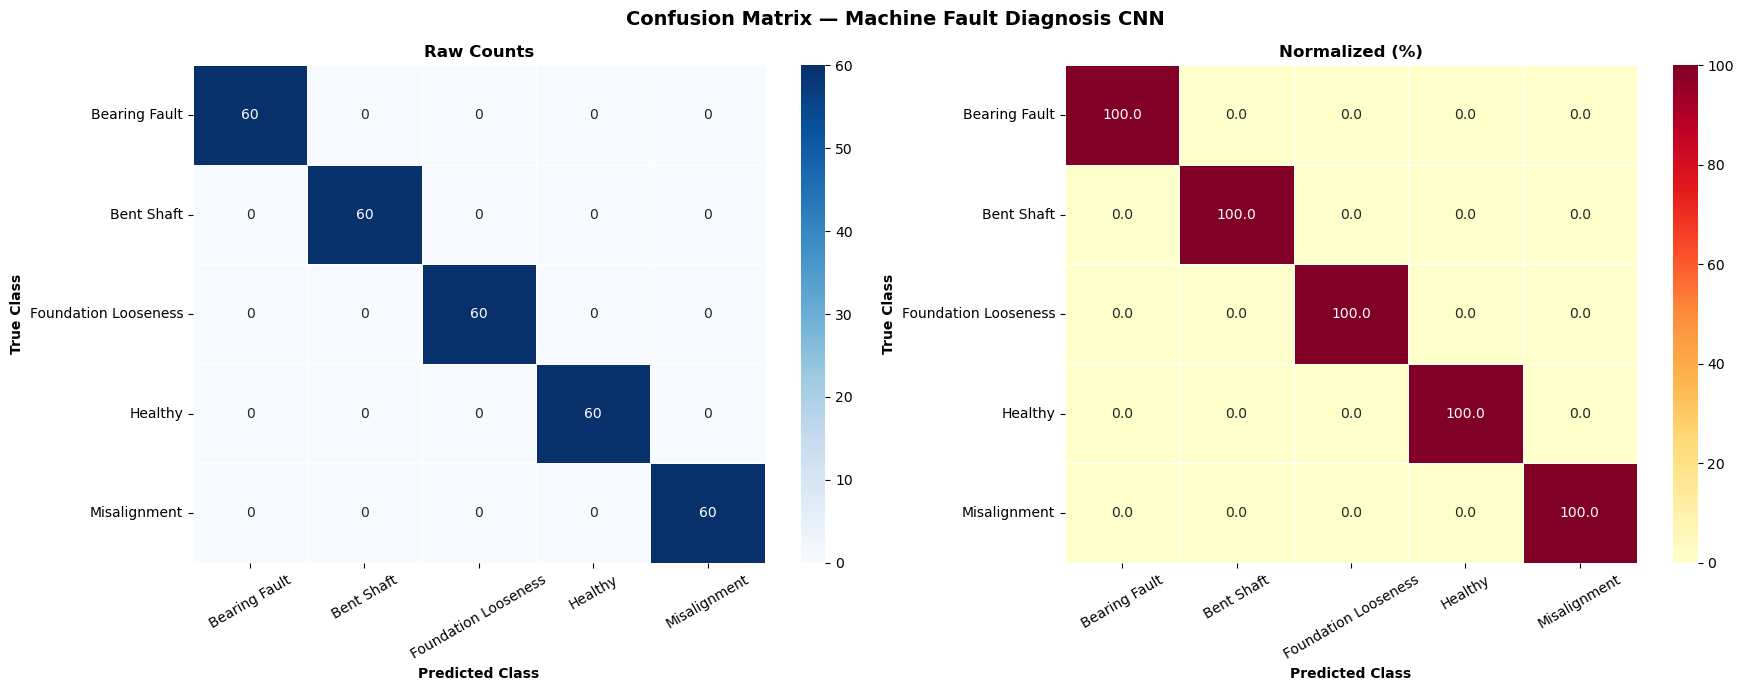

✅ Confusion matrix saved → logs/confusion_matrix.png


In [26]:
from sklearn.metrics import (confusion_matrix,
                              classification_report)
import seaborn as sns

# ── Collect all predictions from test set ─────────────────────
y_true, y_pred = [], []

for images, labels in test_ds:
    # Get model predictions (probabilities)
    preds = best_model.predict(images, verbose=0)

    # Convert one-hot labels → class index
    y_true.extend(np.argmax(labels.numpy(), axis=1))

    # Convert probabilities → predicted class index
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# ── Plot confusion matrix ─────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)

# Normalize to percentages (easier to read)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Confusion Matrix — Machine Fault Diagnosis CNN',
             fontsize=14, fontweight='bold')

# Left: raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Raw Counts', fontweight='bold')
axes[0].set_xlabel('Predicted Class', fontweight='bold')
axes[0].set_ylabel('True Class',      fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)

# Right: normalized percentages
sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='YlOrRd',
            xticklabels=class_names,
            yticklabels=class_names,
            linewidths=0.5, ax=axes[1])
axes[1].set_title('Normalized (%)', fontweight='bold')
axes[1].set_xlabel('Predicted Class', fontweight='bold')
axes[1].set_ylabel('True Class',      fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('logs/confusion_matrix.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("✅ Confusion matrix saved → logs/confusion_matrix.png")

  Per-Class Classification Report
                      precision    recall  f1-score   support

       Bearing Fault     1.0000    1.0000    1.0000        60
          Bent Shaft     1.0000    1.0000    1.0000        60
Foundation Looseness     1.0000    1.0000    1.0000        60
             Healthy     1.0000    1.0000    1.0000        60
        Misalignment     1.0000    1.0000    1.0000        60

            accuracy                         1.0000       300
           macro avg     1.0000    1.0000    1.0000       300
        weighted avg     1.0000    1.0000    1.0000       300



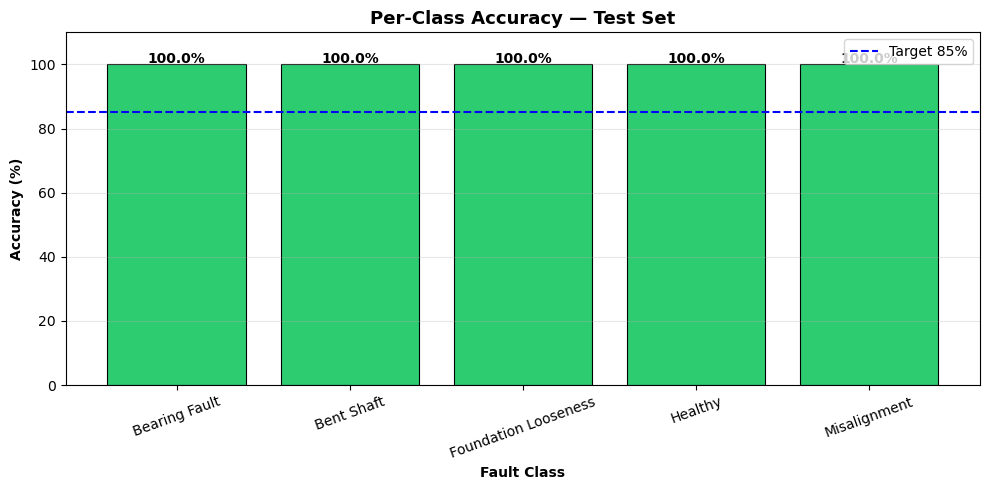

✅ Per-class chart saved → logs/per_class_accuracy.png


In [27]:
# ════════════════════════════════════════════════════════════════
# Classification report gives per-class breakdown:
#   Precision : of all predicted as class X, how many were X?
#   Recall    : of all true class X, how many did we catch?
#   F1-score  : harmonic mean of precision & recall
#   Support   : total test images per class
# ════════════════════════════════════════════════════════════════

print("=" * 65)
print("  Per-Class Classification Report")
print("=" * 65)

report = classification_report(
    y_true, y_pred,
    target_names = class_names,
    digits       = 4
)
print(report)

# ── Per-class accuracy bar chart ──────────────────────────────
per_class_acc = cm.diagonal() / cm.sum(axis=1) * 100

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(class_names, per_class_acc,
              color=['#2ECC71' if a >= 85 else '#E74C3C'
                     for a in per_class_acc],
              edgecolor='black', linewidth=0.8)

# Add value labels on top of each bar
for bar, acc in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{acc:.1f}%',
            ha='center', fontsize=10, fontweight='bold')

ax.axhline(y=85, color='blue', linestyle='--',
           linewidth=1.5, label='Target 85%')
ax.set_title('Per-Class Accuracy — Test Set',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Fault Class',  fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontweight='bold')
ax.set_ylim(0, 110)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('logs/per_class_accuracy.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("✅ Per-class chart saved → logs/per_class_accuracy.png")

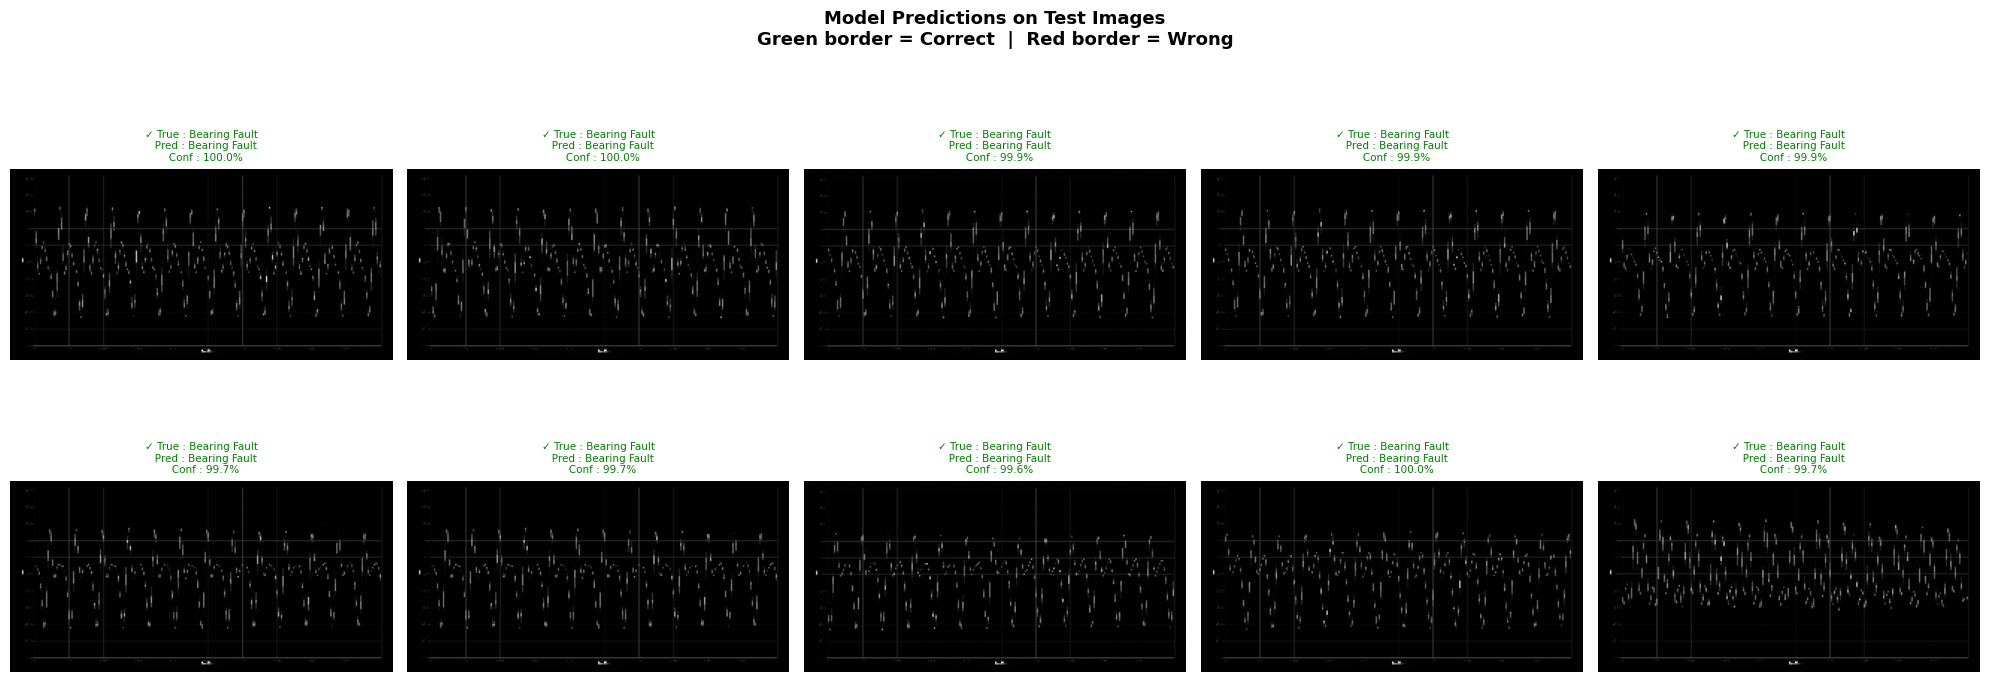

✅ Prediction samples saved → logs/prediction_samples.png


In [28]:
def visualize_predictions(dataset, model, class_names, n=10):
    """
    Shows real test images with:
      - True label (green = correct, red = wrong)
      - Predicted label
      - Confidence percentage
    """
    for images, labels in dataset.take(1):
        preds      = model.predict(images, verbose=0)
        true_idxs  = np.argmax(labels.numpy(),  axis=1)
        pred_idxs  = np.argmax(preds,            axis=1)
        confidences = np.max(preds,              axis=1)

        fig, axes = plt.subplots(2, 5, figsize=(20, 8))
        fig.suptitle(
            'Model Predictions on Test Images\n'
            'Green border = Correct  |  Red border = Wrong',
            fontsize=13, fontweight='bold')

        for i, ax in enumerate(axes.flat):
            img       = images[i, :, :, 0].numpy()
            true_name = class_names[true_idxs[i]]
            pred_name = class_names[pred_idxs[i]]
            conf      = confidences[i]
            correct   = true_idxs[i] == pred_idxs[i]

            ax.imshow(img, cmap='gray')

            # Green border for correct, red for wrong
            for spine in ax.spines.values():
                spine.set_edgecolor('#2ECC71' if correct else '#E74C3C')
                spine.set_linewidth(4)

            status = '✓' if correct else '✗'
            ax.set_title(
                f"{status} True : {true_name}\n"
                f"   Pred : {pred_name}\n"
                f"   Conf : {conf:.1%}",
                fontsize=7.5,
                color='green' if correct else 'red')
            ax.axis('off')

        plt.tight_layout()
        plt.savefig('logs/prediction_samples.png', dpi=150,
                    bbox_inches='tight')
        plt.show()
        print("✅ Prediction samples saved → logs/prediction_samples.png")

visualize_predictions(test_ds, best_model, class_names)

In [29]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

def predict_image(img_path, model, class_names, img_size=(128, 256)):
    # Load image
    img = tf.keras.utils.load_img(img_path, color_mode='grayscale', target_size=img_size)
    
    # Convert to array
    img_array = tf.keras.utils.img_to_array(img)
    
    # Normalize (IMPORTANT: same as training)
    img_array = img_array / 255.0
    
    # Add batch dimension
    img_array = np.expand_dims(img_array, axis=0)

    # Prediction
    preds = model.predict(img_array, verbose=0)
    pred_idx = np.argmax(preds)
    confidence = np.max(preds)

    # Result
    pred_class = class_names[pred_idx]

    # Show image
    plt.imshow(img_array[0, :, :, 0], cmap='gray')
    plt.title(f"Predicted: {pred_class}\nConfidence: {confidence:.2%}")
    plt.axis('off')
    plt.show()

    print(f"✅ Predicted Class: {pred_class}")
    print(f"📊 Confidence: {confidence:.2%}")

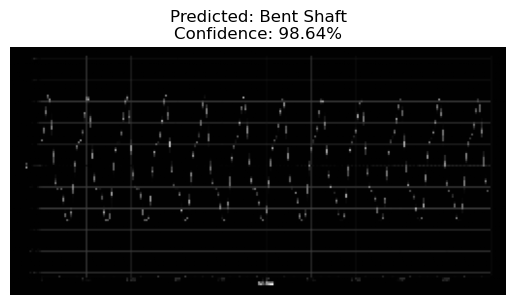

✅ Predicted Class: Bent Shaft
📊 Confidence: 98.64%


In [36]:
predict_image("E:\Vedant Giri\Major Project\Dataset\Test\Bent Shaft\CH2\BentCH2_00021.png", best_model, class_names)

In [31]:

os.makedirs("major_project", exist_ok=True)
best_model.save("major_project_model.keras")

In [32]:
import tensorflow as tf
model = tf.keras.models.load_model("major_project_model.keras")
print(model.input_shape)

(None, 128, 256, 1)


In [33]:
import os

# ── Creates the folder if it doesn't exist ────────────────────
os.makedirs("saved_models", exist_ok=True)

# ── Save with the exact name app.py expects ───────────────────
model.save("saved_models/best_model.keras")

# ── Verify it saved correctly ─────────────────────────────────
if os.path.exists("saved_models/best_model.keras"):
    size_mb = os.path.getsize("saved_models/best_model.keras") / (1024*1024)
    print(f"✅ Model saved successfully!")
    print(f"   Path : saved_models/best_model.keras")
    print(f"   Size : {size_mb:.1f} MB")
else:
    print("❌ Save failed — check folder permissions")

# ── Also print the FULL absolute path ─────────────────────────
# Copy this path — you'll need it in Step 2 below
import pathlib
full_path = pathlib.Path("saved_models/best_model.keras").resolve()
print(f"\n   Full path: {full_path}")

✅ Model saved successfully!
   Path : saved_models/best_model.keras
   Size : 14.4 MB

   Full path: C:\Users\HP\Python\saved_models\best_model.keras


In [42]:
# ============================================================
# FULL DIAGNOSTIC — Run this in Jupyter FIRST
# Paste the complete output here so we can fix app.py exactly
# ============================================================
import os
import numpy as np
import tensorflow as tf
from PIL import Image
import pathlib

print("=" * 60)
print("  FULL DIAGNOSTIC REPORT")
print("=" * 60)

# ── 1. Model path ─────────────────────────────────────────────
model_path = "saved_models/best_model.keras"
print(f"\n[1] Model file exists : {os.path.exists(model_path)}")
print(f"    Full path         : {pathlib.Path(model_path).resolve()}")

# ── 2. Load model ─────────────────────────────────────────────
best_model = tf.keras.models.load_model(model_path)
print(f"\n[2] Model loaded      : ✅")
print(f"    Input  shape      : {best_model.input_shape}")
print(f"    Output shape      : {best_model.output_shape}")
print(f"    Total params      : {best_model.count_params():,}")

# ── 3. Class names from training folder ───────────────────────
TRAIN_DIR = "E:\Vedant Giri\Major Project\Dataset\Train"  # ← your path
class_names_sorted = sorted([
    d for d in os.listdir(TRAIN_DIR)
    if os.path.isdir(os.path.join(TRAIN_DIR, d))
    and not d.startswith('.')
])
print(f"\n[3] CLASS NAMES (sorted — copy to app.py):")
for i, name in enumerate(class_names_sorted):
    print(f"    [{i}] {name}")

# ── 4. Pick one test image ────────────────────────────────────
TEST_DIR = "E:\Vedant Giri\Major Project\Dataset\Test"    # ← your path
test_image = None
true_class = None

for cls in class_names_sorted:
    cls_path = pathlib.Path(TEST_DIR) / cls
    imgs = list(cls_path.rglob("*.[Pp][Nn][Gg]"))
    if imgs:
        test_image = str(imgs[0])
        true_class = cls
        break

print(f"\n[4] Test image found  : {test_image}")
print(f"    True class        : {true_class}")

# ── 5. Preprocess EXACTLY like training ───────────────────────
IMG_H, IMG_W = 128, 256

def preprocess_tf(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=1)
    img = tf.image.resize(img, [IMG_H, IMG_W])
    img = tf.cast(img, tf.float32) / 255.0
    img = tf.expand_dims(img, axis=0)
    return img

img_array = preprocess_tf(test_image)

print(f"\n[5] Preprocessed shape: {img_array.shape}")
print(f"    Pixel min         : {img_array.numpy().min():.4f}")
print(f"    Pixel max         : {img_array.numpy().max():.4f}")
print(f"    Pixel mean        : {img_array.numpy().mean():.4f}")

# ── 6. Run prediction ─────────────────────────────────────────
preds = best_model.predict(img_array, verbose=0)[0]

print(f"\n[6] RAW PROBABILITIES:")
for i, (name, prob) in enumerate(zip(class_names_sorted, preds)):
    bar   = "█" * int(prob * 40)
    arrow = " ← PREDICTED" if i == np.argmax(preds) else ""
    print(f"    [{i}] {name:<40} {prob*100:>6.2f}%  {bar}{arrow}")

pred_idx   = np.argmax(preds)
confidence = preds[pred_idx]
print(f"\n    Predicted : [{pred_idx}] {class_names_sorted[pred_idx]}")
print(f"    True      : {true_class}")
print(f"    Correct   : {'✅ YES' if class_names_sorted[pred_idx] == true_class else '❌ NO'}")
print(f"    Confidence: {confidence*100:.2f}%")

# ── 7. Streamlit-style PIL preprocess comparison ──────────────
def preprocess_pil(path):
    img = Image.open(path).convert('L')
    img = img.resize((IMG_W, IMG_H))
    img = np.array(img, dtype=np.float32) / 255.0
    img = np.expand_dims(img, axis=0)
    img = np.expand_dims(img, axis=-1)
    return img

img_pil   = preprocess_pil(test_image)
preds_pil = best_model.predict(img_pil, verbose=0)[0]

print(f"\n[7] PIL vs TF comparison:")
print(f"    TF  prediction  : [{np.argmax(preds)}]     "
      f"{class_names_sorted[np.argmax(preds)]} "
      f"({preds.max()*100:.1f}%)")
print(f"    PIL prediction  : [{np.argmax(preds_pil)}]     "
      f"{class_names_sorted[np.argmax(preds_pil)]} "
      f"({preds_pil.max()*100:.1f}%)")
print(f"    Match           : "
      f"{'✅ Same' if np.argmax(preds)==np.argmax(preds_pil) else '❌ Different'}")

print("\n" + "=" * 60)
print("  Copy this entire output and share it")
print("=" * 60)

  FULL DIAGNOSTIC REPORT

[1] Model file exists : True
    Full path         : C:\Users\HP\Python\saved_models\best_model.keras

[2] Model loaded      : ✅
    Input  shape      : (None, 128, 256, 1)
    Output shape      : (None, 5)
    Total params      : 1,243,621

[3] CLASS NAMES (sorted — copy to app.py):
    [0] Bearing Fault
    [1] Bent Shaft
    [2] Foundation Looseness
    [3] Healthy
    [4] Misalignment

[4] Test image found  : E:\Vedant Giri\Major Project\Dataset\Test\Bearing Fault\CH1\BearingFaultCH1_00003.png
    True class        : Bearing Fault

[5] Preprocessed shape: (1, 128, 256, 1)
    Pixel min         : 0.1412
    Pixel max         : 0.7137
    Pixel mean        : 0.1552

[6] RAW PROBABILITIES:
    [0] Bearing Fault                             99.99%  ███████████████████████████████████████ ← PREDICTED
    [1] Bent Shaft                                 0.00%  
    [2] Foundation Looseness                       0.01%  
    [3] Healthy                               

## 🧠 Model Optimization Strategies